# 🌳 Drzewa decyzyjne – rozszerzona wersja wykładu

W tej wersji:
- wizualizujemy sektory decyzyjne,
- pokazujemy dane dobrze separowalne i wymieszane,
- analizujemy wpływ max_depth,
- dokładnie badamy zbiór Iris.

## 🔧 Import bibliotek

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import load_iris, make_moons
from sklearn.model_selection import train_test_split

np.random.seed(0)

# 🟢 CZĘŚĆ 1 – Dane dobrze separowalne

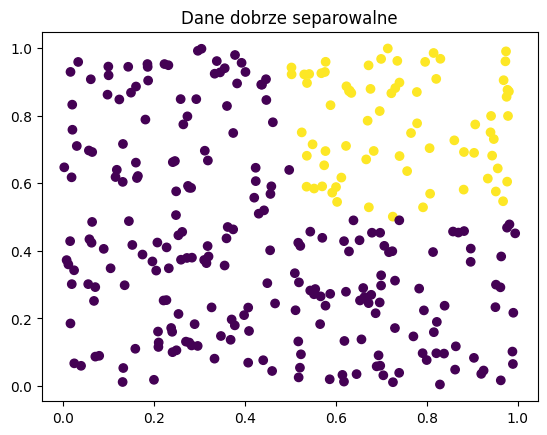

In [2]:
X = np.random.rand(300, 2)
y = ((X[:, 0] > 0.5) & (X[:, 1] > 0.5)).astype(int)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Dane dobrze separowalne")
plt.show()

## Funkcja rysująca sektory decyzyjne

In [3]:
def plot_decision_boundary(clf, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')
    plt.title(title)
    plt.show()

## Testujemy różne głębokości drzewa

max_depth=1, skuteczność=0.78


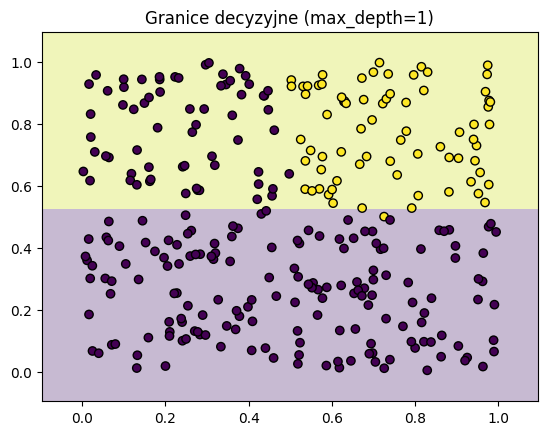

max_depth=2, skuteczność=0.9966666666666667


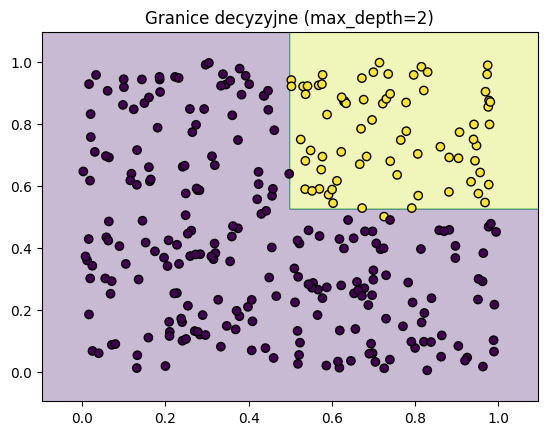

max_depth=4, skuteczność=1.0


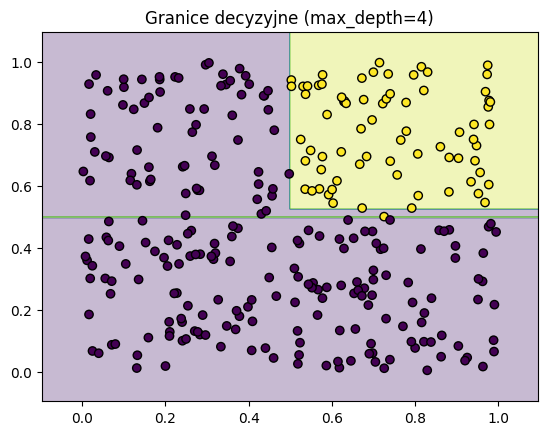

In [4]:
for depth in [1, 2, 4]:
    clf = DecisionTreeClassifier(max_depth=depth)
    clf.fit(X, y)
    acc = clf.score(X, y)
    print(f"max_depth={depth}, skuteczność={acc}")
    plot_decision_boundary(clf, X, y, f"Granice decyzyjne (max_depth={depth})")

# 🟡 CZĘŚĆ 2 – Dane wymieszane (struktura ma znaczenie!)

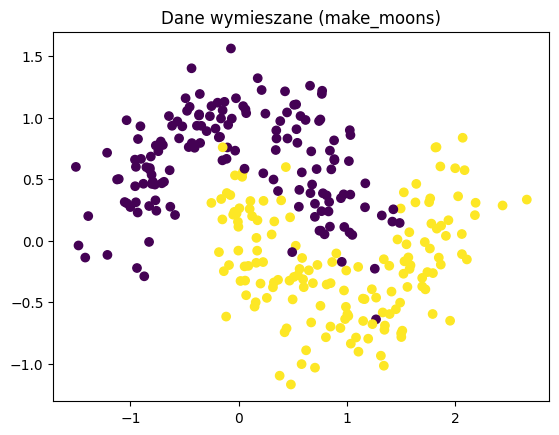

In [5]:
X2, y2 = make_moons(n_samples=300, noise=0.25, random_state=0)

plt.scatter(X2[:, 0], X2[:, 1], c=y2)
plt.title("Dane wymieszane (make_moons)")
plt.show()

max_depth=1, skuteczność=0.8166666666666667


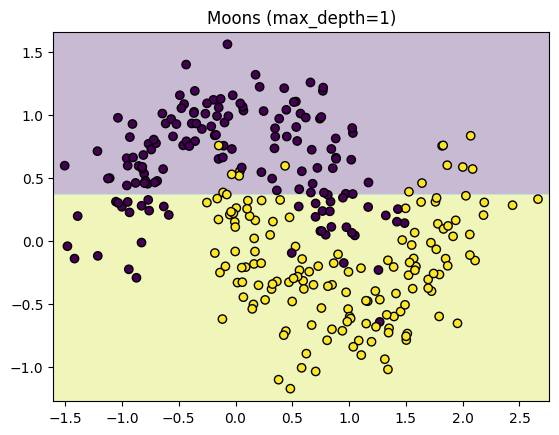

max_depth=3, skuteczność=0.9


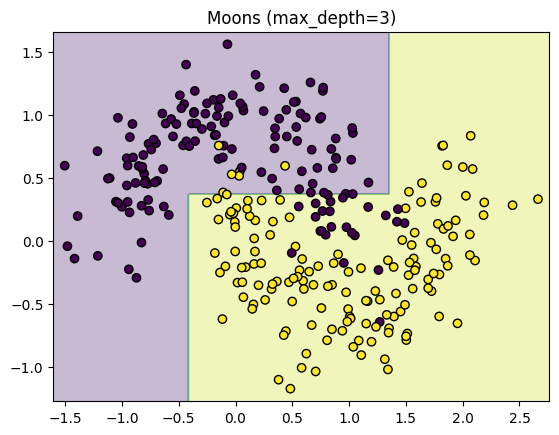

max_depth=6, skuteczność=0.9933333333333333


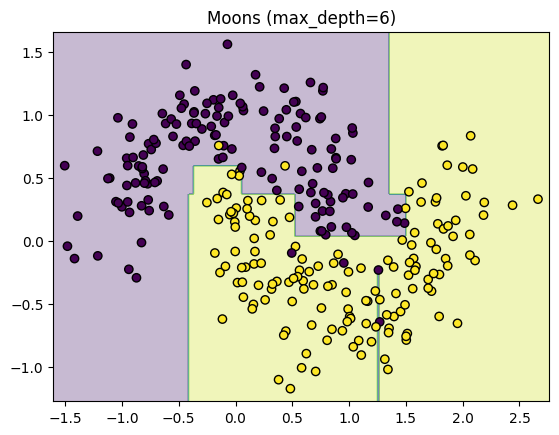

In [6]:
for depth in [1, 3, 6]:
    clf = DecisionTreeClassifier(max_depth=depth)
    clf.fit(X2, y2)
    acc = clf.score(X2, y2)
    print(f"max_depth={depth}, skuteczność={acc}")
    plot_decision_boundary(clf, X2, y2, f"Moons (max_depth={depth})")

Wniosek: drzewa tworzą prostokątne podziały – gdy dane są "zakrzywione", potrzeba głębszych drzew.

# 🌸 CZĘŚĆ 3 – Zbiór Iris

In [7]:
iris = load_iris()
print("Nazwy cech:", iris.feature_names)
print("Nazwy klas:", iris.target_names)
print("Pierwsze 5 wierszy danych:")
print(iris.data[:5])

Nazwy cech: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Nazwy klas: ['setosa' 'versicolor' 'virginica']
Pierwsze 5 wierszy danych:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


## Podział na zbiór treningowy i testowy

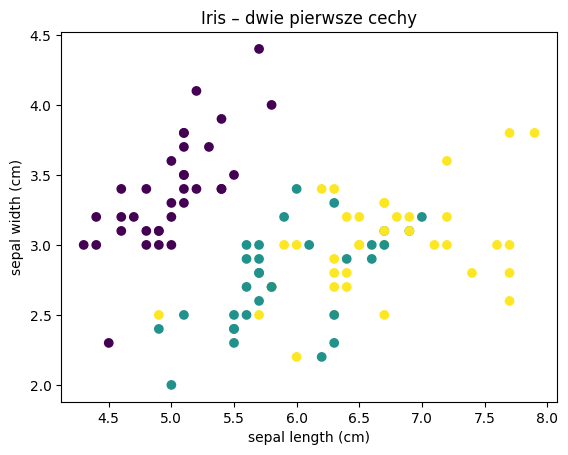

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    iris.data[:, :2], iris.target, test_size=0.3, random_state=0)

plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train)
plt.title("Iris – dwie pierwsze cechy")
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.show()

## Wpływ max_depth na skuteczność

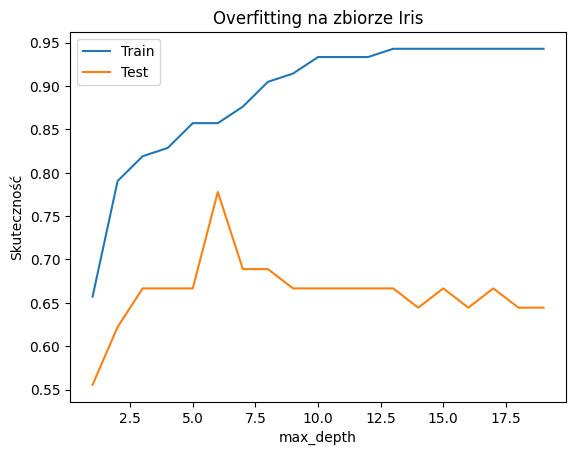

In [11]:
depths = range(1, 20)
train_scores = []
test_scores = []

for depth in depths:
    clf = DecisionTreeClassifier(max_depth=depth)
    clf.fit(X_train, y_train)
    train_scores.append(clf.score(X_train, y_train))
    test_scores.append(clf.score(X_test, y_test))

plt.plot(depths, train_scores, label="Train")
plt.plot(depths, test_scores, label="Test")
plt.xlabel("max_depth")
plt.ylabel("Skuteczność")
plt.legend()
plt.title("Overfitting na zbiorze Iris")
plt.show()

## Wizualizacja sektorów dla różnych głębokości

max_depth=1, skuteczność testowa=0.5555555555555556


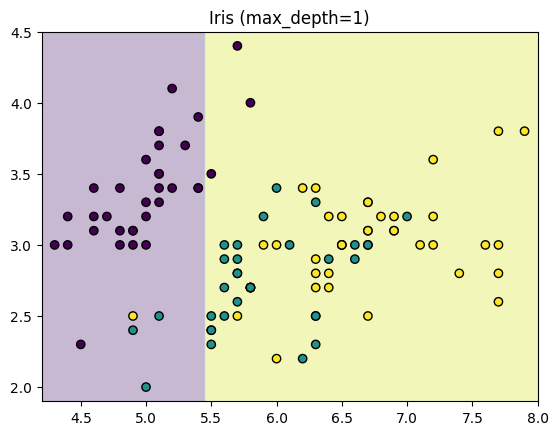

max_depth=3, skuteczność testowa=0.6666666666666666


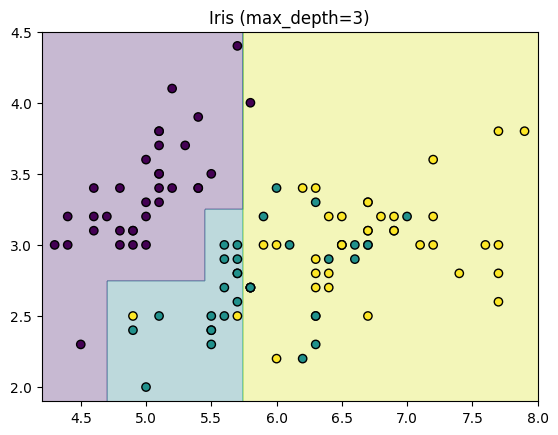

max_depth=6, skuteczność testowa=0.7777777777777778


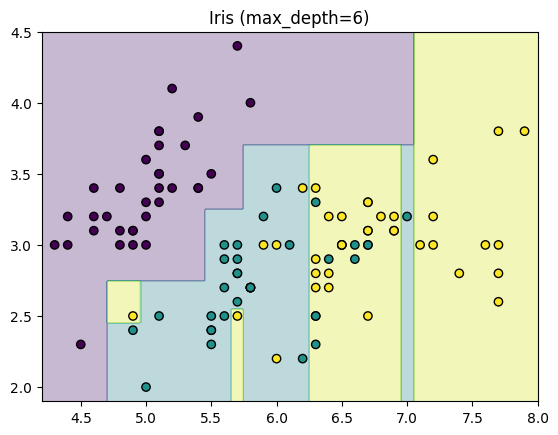

In [10]:
for depth in [1, 3, 6]:
    clf = DecisionTreeClassifier(max_depth=depth)
    clf.fit(X_train, y_train)
    acc = clf.score(X_test, y_test)
    print(f"max_depth={depth}, skuteczność testowa={acc}")
    plot_decision_boundary(clf, X_train, y_train,
                           f"Iris (max_depth={depth})")

# 🔴 Wniosek końcowy

- Drzewa tworzą podziały prostokątne.
- Głębokie drzewa mogą się przeuczać.
- Struktura danych ma ogromne znaczenie.
- Parametr max_depth kontroluje złożoność modelu.